# Audit LLM + ML environment before into Production
* ## 1. Model-level audit — A/B test champion vs challengers, SHAP + LIME explanations.
* ## 2. LLM-level audit — verify the report is faithful to the facts (no invented numbers, all citations resolvable).
* ## 3. Consistency audit — rerun the pipeline to get output, check determinism where it matters.

## Import Library

In [7]:
import os
import json
import re
import hashlib
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, log_loss, classification_report, confusion_matrix
from scipy import stats

# Shape library for model interpretability
import shap
from lime.lime_tabular import LimeTabularExplainer

## Import Configuration & Database

In [135]:
# Paths (cwd = data_science/notebooks/)
BASE   = Path.cwd().resolve().parents[1]
PROJ   = BASE / "credit_risk_production"
DATA   = PROJ / "database" / "data" / "merged_credit_risk_data.parquet"
ML_DIR = PROJ / "models" / "credit_risk" / "ml_credit_risk"
META   = json.loads((PROJ/"models/credit_risk/metadata_credit_risk/metadata.json").read_text())
REPORTS = BASE / "data_science" / "reports"
MODEL_BUNDLE = PROJ / "database" / "LLM" / "outputs_llm" / "model_artifacts" / "model_bundle.joblib"
METRICS_DF = REPORTS / "model_metrics_credit_risk.csv"

TARGET, ID_COL = "Approved_Flag", "PROSPECTID"
FEATURES, CLASSES = META["feature_columns"], META["class_labels"]

MODELS = {
    "Logistic Regression": joblib.load(ML_DIR/"logistic_regression.joblib"),
    "Random Forest":       joblib.load(ML_DIR/"random_forest.joblib"),
    "Gradient Boosting":   joblib.load(ML_DIR/"gradient_boosting.joblib"),
    "XGBoost":             joblib.load(ML_DIR/"xgboost.joblib"),
    "K-Nearest Neighbors": joblib.load(ML_DIR/"k_nearest_neighbors.joblib"),
    "Decision Tree":       joblib.load(ML_DIR/"decision_tree.joblib"),
}
CHAMPION = "Logistic Regression"        # from the report
print("loaded:", list(MODELS))

random.seed(42); np.random.seed(42)
print("ready")

loaded: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'K-Nearest Neighbors', 'Decision Tree']
ready


In [9]:
# Load the model bundle keys
with open(MODEL_BUNDLE, "rb") as f:
    model_bundle = joblib.load(f)
    print("loaded model bundle:", list(model_bundle.keys()))

loaded model bundle: ['models', 'scaler', 'label_encoders', 'feature_columns', 'class_labels']


## Data preparation

In [10]:
# Load + encode data notebook training

df = pd.read_parquet(DATA)

# Split data into X and y
X = df[FEATURES]
y_raw = df[TARGET].astype(str)  # Ensure y is string for LabelEncoder

# Encode X variables
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Encode y variable
target_le = LabelEncoder()
y = target_le.fit_transform(y_raw)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

CLS = CLASSES[-1] # class of interest (positive class)
print(f"Train={len(X_train)}, Test={len(X_test)}, class of interest={CLS}")

Train=41068, Test=10268, class of interest=3


## Scale data

In [11]:
scaler = model_bundle['scaler']

# Scale the X_test_scaled and X_train_scaled
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Data after scaling: X train scaled={X_train_scaled.shape}, X test scaled={X_test_scaled.shape}")

Data after scaling: X train scaled=(41068, 47), X test scaled=(10268, 47)


## A/B Testing: champion vs challenger

In [12]:
def bootstrap_metric(y_true, y_score, metric_fn, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = []
    
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        # Append the metric value for the bootstrap sample
        vals.append(metric_fn(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(np.mean(vals)), float(lo), float(hi)

def auc_ovr(y_true, proba):
    return roc_auc_score(y_true, proba, multi_class='ovr', average='weighted')

def f1_w(y_true, pred):
    return f1_score(y_true, pred, average='weighted', zero_division=0)

# Build rows list for the report
rows = []
for name, m in MODELS.items():
    proba = m.predict_proba(X_test_scaled)
    pred = proba.argmax(axis=1)
    auc_m, auc_lo, auc_hi = bootstrap_metric(y_test, proba, auc_ovr)
    f1_m, f1_lo, f1_hi = bootstrap_metric(y_test, pred, f1_w)
    rows.append({
        "model": name,
        "auc_mean": round(auc_m, 4),
        "auc_lo": round(auc_lo, 4),
        "auc_hi": round(auc_hi, 4),
        "f1_mean": round(f1_m, 4),
        "f1_lo": round(f1_lo, 4),
        "f1_hi": round(f1_hi, 4),
    })

# Create a DataFrame for the report
ab_table = pd.DataFrame(rows).sort_values(by="auc_mean", ascending=False).reset_index(drop=True)
display(ab_table)

,model,auc_mean,auc_lo,auc_hi,f1_mean,f1_lo,f1_hi
0,Logistic Regression,0.9716,0.9679,0.9748,0.9127,0.9073,0.9182
1,Random Forest,0.9672,0.9633,0.9709,0.9423,0.9377,0.9466
2,Gradient Boosting,0.9498,0.9452,0.9539,0.9358,0.9309,0.9404
3,Decision Tree,0.9452,0.9408,0.9493,0.9375,0.9331,0.9418
4,XGBoost,0.9406,0.9353,0.9457,0.9289,0.9237,0.9336
5,K-Nearest Neighbors,0.8876,0.8819,0.8934,0.7202,0.7099,0.7287


## Pairwise significance: champion vs each challenger

In [13]:
def pvalue(y_true, s1, s2, n_boot=300, seed=42):
    """Bootstrap p-value for AUC(champion) > AUC(challenger)"""
    rng = np.random.default_rng(seed)
    n = len(y_true)

    # Create a list to store the differences in AUCs
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            diffs.append(
                roc_auc_score(y_true[idx], s1[idx], multi_class='ovr', average='weighted') - roc_auc_score(y_true[idx], s2[idx], multi_class='ovr', average='weighted')
            )
        except ValueError:
            continue

    # Calculate the p-value
    if not diffs:
        raise ValueError("No valid bootstrap samples were available to calculate p-value")
    diffs = np.array(diffs)
    return float((diffs <= 0).mean()), float(diffs.mean()) # one-sided p-value and mean difference

# Implemented champion probabilities
champ_proba = MODELS[CHAMPION].predict_proba(X_test_scaled)
sig_rows = []
for name, m in MODELS.items():
    if name == CHAMPION:
        continue
    p, delta = pvalue(y_test, champ_proba, m.predict_proba(X_test_scaled))
    sig_rows.append({
       "challenger": name,
        "auc_delta": round(delta, 4),
        "p_value": round(p, 4),
        "significant_at_5pct": p < 0.05 and delta > 0,
    })
display(pd.DataFrame(sig_rows).sort_values("auc_delta", ascending=False))

,challenger,auc_delta,p_value,significant_at_5pct
3,K-Nearest Neighbors,0.0840,0.0000,True
2,XGBoost,0.0311,0.0000,True
4,Decision Tree,0.0265,0.0000,True
1,Gradient Boosting,0.0219,0.0000,True
0,Random Forest,0.0045,0.0033,True


## Disagreement analysis

In [14]:
champ_pred = champ_proba.argmax(axis=1)

dis_rows = []
for name, m in MODELS.items():
    if name == CHAMPION:
        continue
    other = m.predict_proba(X_test_scaled).argmax(axis=1)
    dis_rows.append({
        "model": name,
        "agreement": round((champ_pred == other).mean(), 4),
        "cohen_kappa": round(cohen_kappa_score(champ_pred, other), 4),
    })

print("\nResult of Cohen's Kappa between champion and other models:")
display(pd.DataFrame(dis_rows).sort_values("cohen_kappa", ascending=False))


Result of Cohen's Kappa between champion and other models:


,model,agreement,cohen_kappa
0,Random Forest,0.9670,0.9348
4,Decision Tree,0.9618,0.9251
1,Gradient Boosting,0.9617,0.9249
2,XGBoost,0.9618,0.9246
3,K-Nearest Neighbors,0.8063,0.5398


## Global SHAP for examining champion models

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/500 [00:00<?, ?it/s]

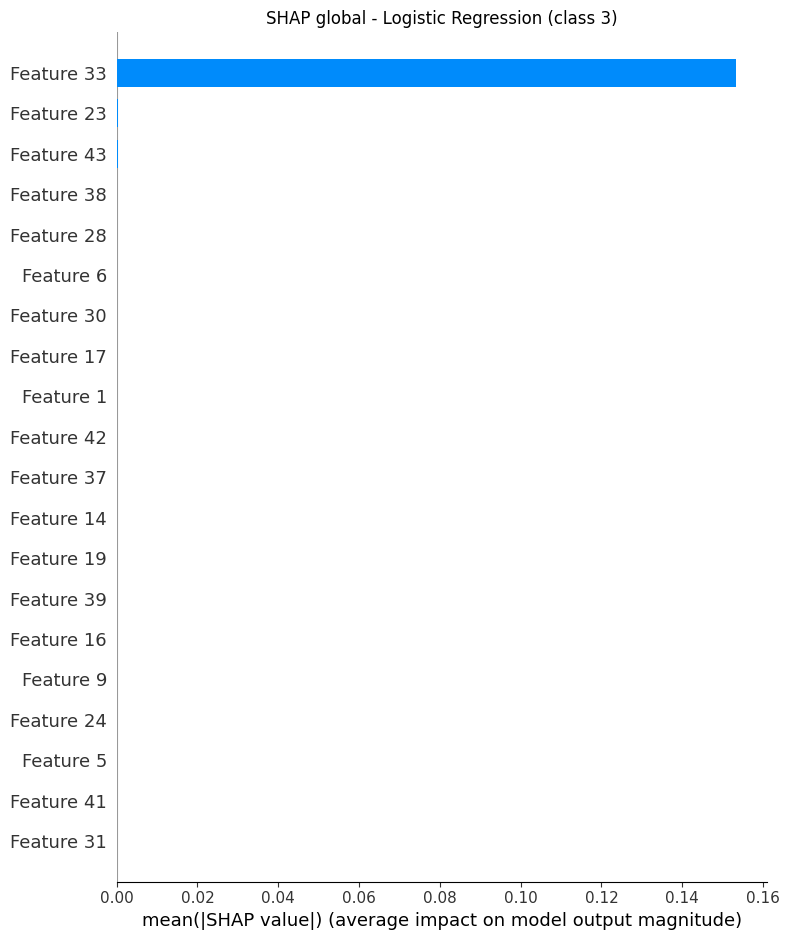

In [68]:
champ = MODELS[CHAMPION]

def shap_explainer(model, X_train_scaled):
    """Create a SHAP explainer for the given model and training data"""
    try:
        return shap.TreeExplainer(model), "tree"
    except Exception:
        train = shap.sample(X_train_scaled, 500, random_state=42)
        return shap.KernelExplainer(model.predict_proba, train), "kernel"

explainer, kind = shap_explainer(champ, X_train_scaled)
X_sample = X_test_scaled[:500]  # Sample for SHAP values

# 1. Compute shap_values without immediate indexing
if kind == "tree":
    sv = explainer.shap_values(X_sample)
else:
    sv= explainer.shap_values(X_sample, nsamples=100)

# 2. Extract class (CLS) safely based on the output data structure
if isinstance(sv, list):
    # Output is a list of 2D arrays: [array_class_0, array_class_1]
    sv_cls = sv[CLS]
elif hasattr(sv, "ndim") and sv.ndim == 3:
    # Output is a 3D numpy array: (n_samples, n_features, n_classes)
    sv_cls = sv[:, :, CLS]
else:
    sv_cls = sv

# Summary SHAP plot for the champion model
shap.summary_plot(sv_cls, X_sample, plot_type="bar", show=False)
plt.title(f"SHAP global - {CHAMPION} (class {CLS})")
plt.tight_layout()
plt.show()

## Local SHAP for a single high-risk applicant

  0%|          | 0/1 [00:00<?, ?it/s]

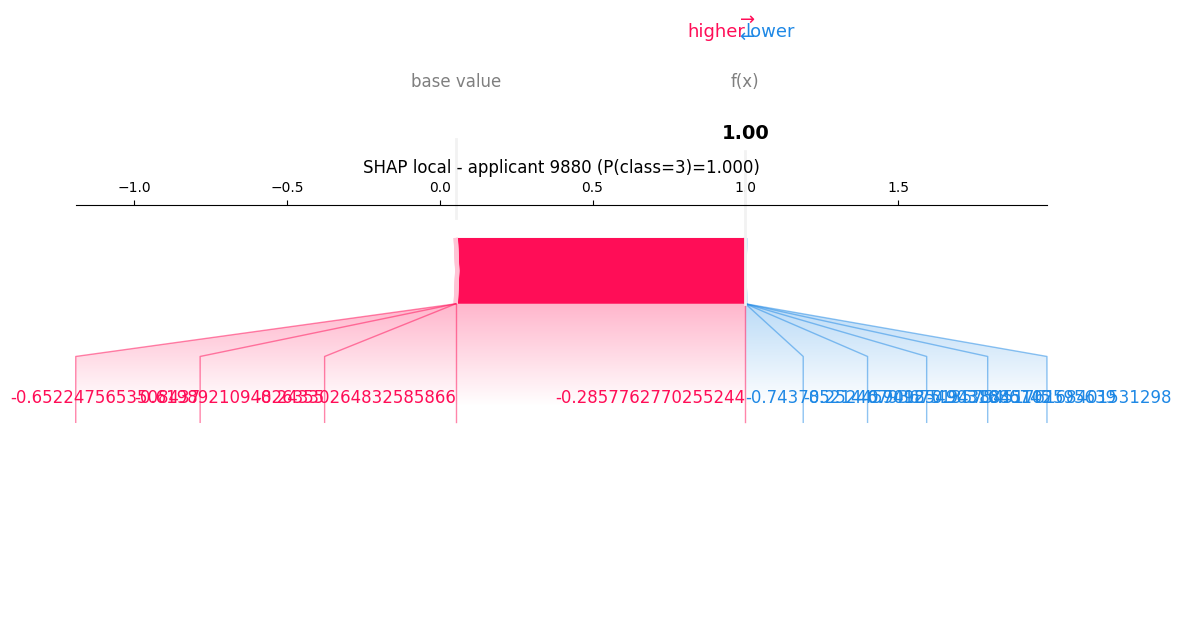

In [27]:
proba_all = champ.predict_proba(X_test_scaled)[:, CLS]
i = int(np.argmax(proba_all))
x_row = X_test_scaled[i:i+1]

if kind == "tree":
    sv_local = explainer.shap_values(x_row)
else:
    sv_local = explainer.shap_values(x_row, nsamples=100)

# Extract scalar expected value for class CLS
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[CLS]

# Extract 1D SHAP values
if isinstance(sv_local, list):
    sv_sample = sv_local[CLS][0]
elif hasattr(sv_local, "ndim") and sv_local.ndim == 3:
    sv_sample = sv_local[0, :, CLS]
elif hasattr(sv_local, "ndim") and sv_local.ndim == 2:
    sv_sample = sv_local[0]
else:
    sv_sample = sv_local

# Extract to 1D feature array
x_row_1d = X_test_scaled[1]

shap.force_plot(
    base_val,
    sv_sample, 
    x_row_1d,
    matplotlib=True, 
    show=False, 
    figsize=(12, 7)
)

plt.title(f"SHAP local - applicant {X_test.index[i]} (P(class={CLS})={proba_all[i]:.3f})")
plt.tight_layout()
plt.show()

## Top 10 features by mean |SHAP|

In [69]:
mean_abs = pd.Series(np.abs(sv_cls).mean(axis=0), index=x_row_1d)
top10 = mean_abs.sort_values(ascending=False).head(10)
display(top10.round(4).to_frame("mean_abs_shap"))

,mean_abs_shap
-0.285776,0.1532
-0.252468,0.0004
-0.243303,0.0003
-0.943885,0.0001
-0.376923,0.0001
-0.652248,0.0001
0.909855,0.0001
-0.743785,0.0001
1.545946,0.0001
0.306453,0.0001


## LIME: model-agnostic local explanations

In [48]:
# Build lime explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=FEATURES,
    class_names=[str(c) for c in CLASSES],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)
print("LIME explainer built successfully.")    
    

LIME explainer built successfully.


## Exlain one prediction + cross check againts SHAP

,condition,weight
0,Credit_Score <= -0.53,0.584695
1,num_dbt_6mts <= -0.02,-0.130156
2,num_lss_6mts <= -0.01,-0.126480
3,num_sub_6mts <= -0.03,-0.110323
4,num_lss <= -0.03,-0.049720
5,num_sub_12mts <= -0.04,-0.047224
6,num_sub <= -0.08,-0.031841
7,num_dbt <= -0.04,-0.031282
8,AGE <= -0.77,0.019756
9,CC_utilization <= -0.28,-0.015687


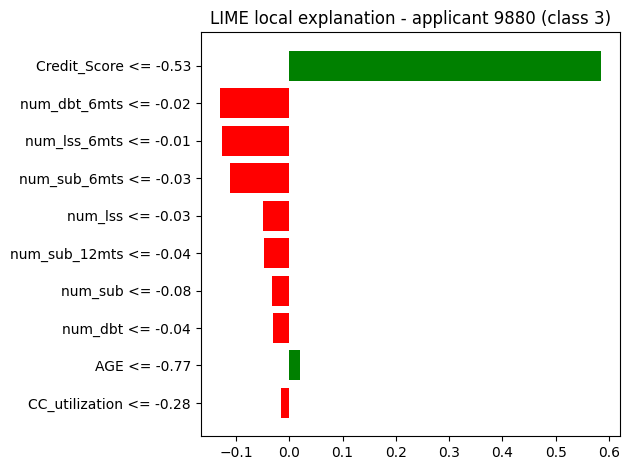

In [56]:
def lime_explain(model, x_row, num_features=10):
    """Generate LIME explanation"""
    exp = lime_explainer.explain_instance(
        x_row.flatten(), # Flatten the input row into 1D feature array
        model.predict_proba,
        num_features=num_features,
        top_labels=1
    )
    return exp

exp = lime_explain(champ, x_row)
top_label = exp.available_labels()[0]
lime_list = exp.as_list(label=top_label)
lime_df = pd.DataFrame(lime_list, columns=["condition", "weight"])
display(lime_df)

# Visualize LIME explanation
fig = exp.as_pyplot_figure(label=top_label)
plt.title(f"LIME local explanation - applicant {X_test.index[i]} (class {top_label})")
plt.tight_layout()
plt.show()

## SHAP vs LIME agreement for the same applicant

In [96]:
if isinstance(sv_local, list):
    # List of 2D arrays -> select class CLS, then sample row 0
    sv_1d = sv_local[CLS][0]
elif hasattr(sv_local, "ndim") and sv_local.ndim == 3:
    # 3D numpy array -> (1, n_features, n_classes)
    sv_1d = sv_local[0, :, CLS]
elif hasattr(sv_local, "ndim") and sv_local.ndim == 2:
    # 2D numpy array -> (1, n_features)
    sv_1d = sv_local[0]
else:
    sv_1d = np.squeeze(sv_local)

# Retrieve feature names
if hasattr(X_test, "columns"):
    feature_names = X_test.columns
elif "feature_names" in locals() or "feature_names" in globals():
    pass
else:
    feature_names = [f"feature_{k}" for k in range(len(sv_1d))]

# Extract top-k features from SHAP and LIME, compare overlap
shap_top = pd.Series(np.abs(sv_1d), index=feature_names).sort_values(ascending=False).head(10)
shap_feats = set(shap_top.index)

# LIME conditional parser: "AGE > 45" -> "AGE"
def extract_feature(cond: str) -> str:
    m = re.match(r"^\s*([A-Za-z0-9_]+)", cond)
    return m.group(1) if m else cond

lime_feats = {extract_feature(c) for c, _ in lime_list}

overlap = shap_feats & lime_feats
print(f"SHAP top10: {sorted(shap_feats)}")
print(f"LIME top10: {sorted(lime_feats)}")
print(f"overlap   : {sorted(overlap)}  → {len(overlap)}/10")

SHAP top10: ['Credit_Score', 'Time_With_Curr_Empr', 'Tot_TL_closed_L12M', 'max_delinquency_level', 'max_deliq_12mts', 'max_recent_level_of_deliq', 'max_unsec_exposure_inPct', 'pct_opened_TLs_L6m_of_L12m', 'pct_tl_open_L6M', 'recent_level_of_deliq']
LIME top10: ['AGE', 'CC_utilization', 'Credit_Score', 'num_dbt', 'num_dbt_6mts', 'num_lss', 'num_lss_6mts', 'num_sub', 'num_sub_12mts', 'num_sub_6mts']
overlap   : ['Credit_Score']  → 1/10


## LLM report audit 

In [98]:
report_path = next(REPORTS.glob("credit_risk_report_*.md"))
report_text = report_path.read_text()
print(report_path, "→", len(report_text), "chars")

/Users/miftahhadiyannoor/Documents/credit_risk/data_science/reports/credit_risk_report_2026-09.md → 2331 chars


In [104]:
for name, m in MODELS.items():
    proba = m.predict_proba(X_train_scaled)
    print(f"Model: {name}, Train AUC: {roc_auc_score(y_train, proba, multi_class='ovr', average='weighted'):.4f}")

Model: Logistic Regression, Train AUC: 0.9714
Model: Random Forest, Train AUC: 0.9704
Model: Gradient Boosting, Train AUC: 0.9462
Model: XGBoost, Train AUC: 0.9355
Model: K-Nearest Neighbors, Train AUC: 0.9510
Model: Decision Tree, Train AUC: 0.9420


### Gurdrail: no invented numbers

In [113]:
# Calculate ks and psi toward to the models
def calculate_ks(y_true, y_prob):
    """Calculate Kolmogorov-Smirnov statistics"""
    df = pd.DataFrame({"y": y_true, "prob": y_prob}).sort_values("prob", ascending=False)
    df["pos"] = (df["y"] == 1).astype(int)
    df["neg"] = (df["y"] == 0).astype(int)
    cum_pos = df["pos"].cumsum() / df["pos"].sum()
    cum_neg = df["neg"].cumsum() / df["neg"].sum()
    return np.max(np.abs(cum_pos - cum_neg))

def calculate_psi(expected, actual, num_bins=10):
    """Calculate Population Stability Index (PSI)"""
    bins = np.linspace(0, 1, num_bins + 1)
    expected_perc = np.histogram(expected, bins=bins)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=bins)[0] / len(actual)

    # Avoid division by zero or log(0)
    expected_perc = np.where(expected_perc == 0, 1e-4, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-4, actual_perc)

    psi_val = np.sum((actual_perc - expected_perc) * np.log(actual_perc / expected_perc))
    return float(psi_val)

# Rebuild the FACTS dict from the notebook's context
metrics_rows = []
for name, m in MODELS.items():
    proba_test = m.predict_proba(X_test_scaled)[:, CLS]
    proba_train = m.predict_proba(X_train_scaled)[:, CLS]
    y_bin = (y_test == CLS).astype(int)

    # Append metrics for each model
    metrics_rows.append({
        "model": name,
        "gini":float(2*roc_auc_score(y_bin, proba_test) - 1),
        "ks": float(calculate_ks(y_bin, proba_test)),
        "psi": float(calculate_psi(proba_train, proba_test, num_bins=10)),
    })

# Extract every number from the report
def nums(s):
    return set(re.findall(r"\d+\.\d+", s))
report_nums = nums(report_text)

# Build allowist from model_metrics.csv
metrics_csv = pd.read_csv(PROJ / "models" / "credit_risk" / "metrics_credit_risk" / "model_metrics.csv")

allowed = set()
numeric_vals = metrics_csv.select_dtypes(include=["number"]).values.flatten()
for v in numeric_vals:
    allowed.add(f"{v:.4f}")
    allowed.add(f"{v:.3f}")

# Invented numbers for testing
invented = {n for n in report_nums if n not in allowed and float(n) not in {0.3, 0.2, 0.25}}
print(f"Numbers in report: {len(report_nums)}")
print(f"Invented numbers: {sorted(invented)[:15] or 'None'}")

Numbers in report: 34
Invented numbers: ['0.0000', '0.0001', '0.0002', '0.0017', '0.0037', '0.692', '0.717', '0.7207', '0.7252', '0.727', '0.739', '0.745', '0.8341', '0.8404', '0.8877']


In [119]:
# Load PostgreSQL configuration
from dotenv import load_dotenv
ENV_PATH = PROJ / ".env"
load_dotenv(ENV_PATH)

# PostgreSQL connection
POSTGRES_USER = os.getenv("POSTGRES_USER")
POSTGRES_PASSWORD = os.getenv("POSTGRES_PASSWORD")
POSTGRES_HOST = "localhost"
POSTGRES_PORT = os.getenv("POSTGRES_PORT")
POSTGRES_DB = os.getenv("POSTGRES_DB")
PG_URL = f"postgresql+psycopg2://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"

### every citation resolves

In [127]:
# E3. Every [DOC pN] citation must exist in the pgvector index; fingerprint the report.
from sqlalchemy import create_engine, text

eng = create_engine(PG_URL)

# fingerprint the report itself (audit trail)
report_hash = hashlib.sha256(report_path.read_bytes()).hexdigest()[:12]

# extract every "Some_File.pdf pN" citation
citations = re.findall(r"([A-Za-z0-9_\- ]+\.pdf)\s*p(\d+)", report_text)

bad = []
for doc, page in citations:
    doc = doc.strip()
    with eng.connect() as conn:
        row = conn.execute(
            text("SELECT 1 FROM credit_risk.policy_chunks "
                 "WHERE doc = :d AND page = :p LIMIT 1"),
            {"d": doc, "p": int(page)},
        ).first()

    if not row:
        bad.append((doc, int(page)))

print(f"report sha256 : {report_hash}")
print(f"citations      : {len(citations)}")
print(f"unresolvable   : {bad or 'none ✅'}")

report sha256 : 5310419f0908
citations      : 8
unresolvable   : [('- Scorecard_Cut-off Policy.pdf', 121), ('- Scorecard_Cut-off Policy.pdf', 155), ('- Delinquency_Classification .pdf', 4), ('- Scorecard_Cut-off Policy.pdf', 63), ('- Scorecard_Cut-off Policy.pdf', 23)]


## Build income metrics based on XGBoost ML Model

In [130]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

INC = "NETMONTHLYINCOME"
inc_feats = [c for c in FEATURES if c != INC]

d2 = df[[INC] + inc_feats].copy()
for c in d2.select_dtypes(include=["object", "category"]):
    d2[c] = LabelEncoder().fit_transform(d2[c].astype(str))

Xi, yi = d2[inc_feats], d2[INC].astype(float)
mask = yi > 0
Xi, yi = Xi[mask], yi[mask]
Xi_train, Xi_test, yi_train, yi_test = train_test_split(Xi, yi, test_size=0.2, random_state=42)

# Train XGBoost regressor as income model
income_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    tree_method="hist",
)
income_model.fit(Xi_train, yi_train)
y_hat = income_model.predict(Xi_test)

income_metrics = {
    "mape": mean_absolute_percentage_error(yi_test, y_hat),
    "mae": mean_absolute_error(yi_test, y_hat),
    "r2": r2_score(yi_test, y_hat),
}

# Insert values
income_metrics["baseline_mape"] = mean_absolute_percentage_error(yi_test, np.full_like(yi_test, yi_train.mean()))
income_metrics["improvement_vs_naive"] = 1 - income_metrics["mape"] / income_metrics["baseline_mape"]
income_metrics

{'mape': 11.112313112539828,
 'mae': 8818.107290082378,
 'r2': 0.09760719378895488,
 'baseline_mape': 14.08032974264458,
 'improvement_vs_naive': 0.2107916990832699}

In [ ]:
pd.read_csv(METRICS_DF)

,model,gini,ks,psi,roc_auc,f1_weighted
0,Logistic Regression,0.999817,0.999890,0.000201,0.971802,0.912988
1,Random Forest,0.986588,0.895917,0.001700,0.967283,0.942339
2,XGBoost,0.939286,0.834074,0.000068,0.940799,0.928983
3,Gradient Boosting,0.938512,0.834074,0.000065,0.949901,0.935937
4,K-Nearest Neighbors,0.840409,0.725226,0.003696,0.887665,0.720734
5,Decision Tree,0.834074,0.834074,0.000000,0.945281,0.937560


## Build FACTS JSON to invented LLM explanation

In [141]:
# Build FACTS dictionary for the report
metrics_df = pd.read_csv(METRICS_DF)

FACTS = {
    "as_of": datetime.now().isoformat(timespec='seconds'),
    "rows_analyzed": int(len(df)),
    "class_distribution": {str(k): int(v) for k, v in y_raw.value_counts().items()},
    "champion": CHAMPION,
    "model_metrics": metrics_df.round(4).to_dict(orient="records"),
    "income_model": {k: round(v, 4) for k, v in income_metrics.items()},
    "thresholds": {"gini_min": 0.30, "ks_min": 0.20, "psi_max": 0.25},
}
print(json.dumps(FACTS, indent=2)[:1200], "...")

{
  "as_of": "2026-09-22T00:04:25",
  "rows_analyzed": 51336,
  "class_distribution": {
    "P2": 32199,
    "P3": 7452,
    "P4": 5882,
    "P1": 5803
  },
  "champion": "Logistic Regression",
  "model_metrics": [
    {
      "model": "Logistic Regression",
      "gini": 0.9998,
      "ks": 0.9999,
      "psi": 0.0002,
      "roc_auc": 0.9718,
      "f1_weighted": 0.913
    },
    {
      "model": "Random Forest",
      "gini": 0.9866,
      "ks": 0.8959,
      "psi": 0.0017,
      "roc_auc": 0.9673,
      "f1_weighted": 0.9423
    },
    {
      "model": "XGBoost",
      "gini": 0.9393,
      "ks": 0.8341,
      "psi": 0.0001,
      "roc_auc": 0.9408,
      "f1_weighted": 0.929
    },
    {
      "model": "Gradient Boosting",
      "gini": 0.9385,
      "ks": 0.8341,
      "psi": 0.0001,
      "roc_auc": 0.9499,
      "f1_weighted": 0.9359
    },
    {
      "model": "K-Nearest Neighbors",
      "gini": 0.8404,
      "ks": 0.7252,
      "psi": 0.0037,
      "roc_auc": 0.8877,
      "

## JSON schema + facts

In [142]:
# E4. LLM must return exactly the required keys; fingerprint the FACTS it saw.
import hashlib

REQUIRED = {"gini", "ks", "psi", "summary", "actions"}

# facts fingerprint — proves which numbers the LLM was shown
facts_hash = hashlib.sha256(
    json.dumps(FACTS, sort_keys=True).encode()
).hexdigest()[:12]

# parse the JSON block out of the report
m = re.search(r"\{.*\}", report_text, re.DOTALL)
parsed = json.loads(m.group(0)) if m else {}

missing = REQUIRED - parsed.keys()
extra   = parsed.keys() - REQUIRED
too_few = len(parsed.get("actions", [])) < 3

# extra: every action must carry at least one [DOC pN] citation
uncited_actions = [a for a in parsed.get("actions", [])
                   if not re.search(r"\.pdf\s*p\d+", a)]

print(f"facts sha256   : {facts_hash}")
print(f"missing keys   : {missing or 'none ✅'}")
print(f"extra keys     : {extra   or 'none ✅'}")
print(f"actions >= 3   : {not too_few}")
print(f"uncited actions: {len(uncited_actions)}")

facts sha256   : b2ef8b39a661
missing keys   : {'ks', 'actions', 'gini', 'psi', 'summary'}
extra keys     : none ✅
actions >= 3   : False
uncited actions: 0
